In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/nsls2/data/lix/proposals/2025-2/pass-317792/dev/mani/ganrec_updated/ganrec')
from ganrectf.utils import angles, nor_tomo
from ganrectf.ganrec import GANtomo

from ganrectf.propagators import TomoRadon

import tensorflow as tf

2026-01-13 15:13:00.364521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-13 15:13:00.378455: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-13 15:13:00.382715: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-13 15:13:00.394505: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-13 15:13:01.860724: W tensorflow/compiler/tf2

In [2]:
raw_data = np.load('./test_data/SheppLogan_easy.npy')
angs = np.linspace(0,180, 180)

angs_tf = tf.cast(np.deg2rad(angs), dtype = tf.float32)
gtrecon_tf = tf.cast(raw_data[None, ..., None], dtype = tf.float32)

radon_obj = TomoRadon(gtrecon_tf, angs_tf)
sino_gt_tf =  radon_obj.compute()
sino_gt = np.array(sino_gt_tf).squeeze()


prj = sino_gt
ang = np.deg2rad(angs)

2026-01-13 15:13:04.098235: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79193 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:03:00.0, compute capability: 8.0
2026-01-13 15:13:04.099440: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79193 MB memory:  -> device: 1, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:83:00.0, compute capability: 8.0


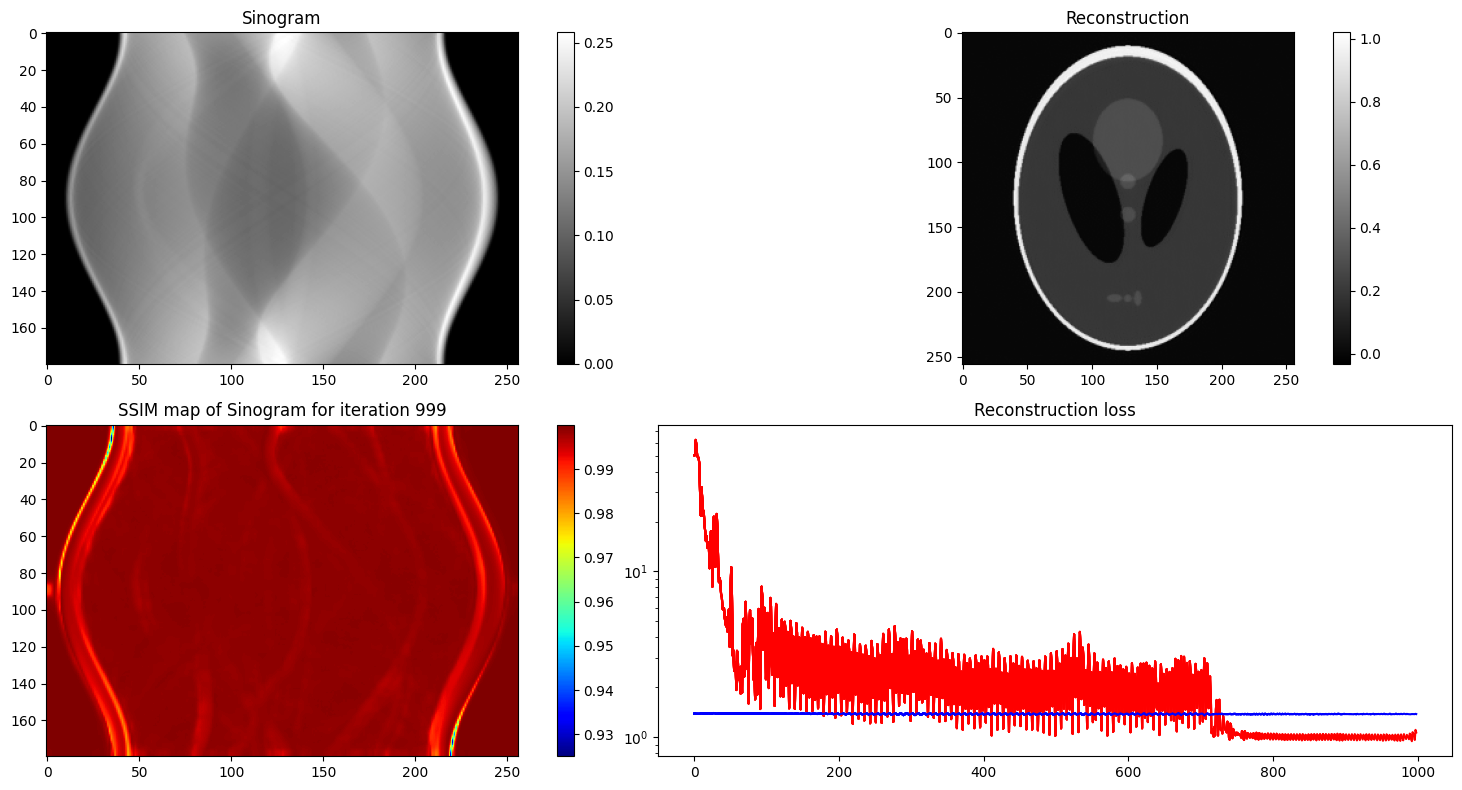

<Figure size 640x480 with 0 Axes>

Reconstruction: 100%|██████████| 1000/1000 [00:28<00:00, 35.07it/s, D_loss=1.3725, G_loss=1.0311]


In [3]:
rec = GANtomo(prj, ang, iter_num=1000, recon_monitor=True).recon()
# rec = engine.recon(prj)

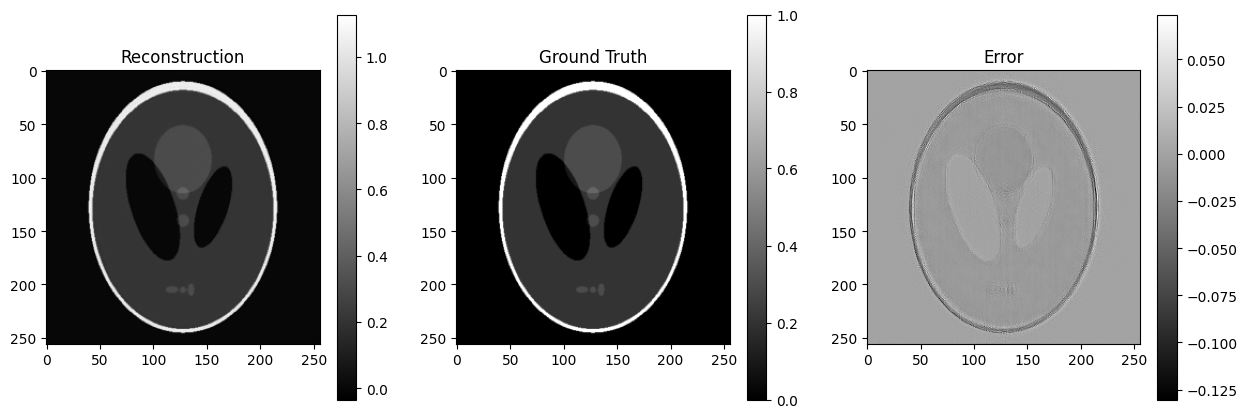

In [4]:
fig, ax = plt.subplots(ncols = 3, figsize = (15,5))

im0 = ax[0].imshow(rec, cmap = 'gray')
ax[0].set_title('Reconstruction')
cbar0 = fig.colorbar(im0, ax = ax[0])

im1 = ax[1].imshow(raw_data, cmap = 'gray')
ax[1].set_title('Ground Truth')
cbar1 = fig.colorbar(im1, ax = ax[1])

im2 = ax[2].imshow(raw_data - rec, cmap = 'gray')
ax[2].set_title('Error')
cbar2 = fig.colorbar(im2, ax = ax[2])